<a href="https://colab.research.google.com/github/Laiba-saeed92/Deep_Learning_projects/blob/main/Transfer_learning_with_VGG16_Fine_tuning(with_DataAugmentation).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
!tar -xvzf flower_photos.tgz


--2025-08-24 21:49:34--  https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.10.207, 142.251.12.207, 64.233.170.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.10.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228813984 (218M) [application/x-compressed-tar]
Saving to: ‘flower_photos.tgz’

flower_photos.tgz   100%[===================>] 218.21M  23.3MB/s    in 11s     

2025-08-24 21:49:46 (20.1 MB/s) - ‘flower_photos.tgz’ saved [228813984/228813984]

flower_photos/
flower_photos/roses/
flower_photos/roses/14810868100_87eb739f26_m.jpg
flower_photos/roses/1446090416_f0cad5fde4.jpg
flower_photos/roses/15319767030_e6c5602a77_m.jpg
flower_photos/roses/15032112248_30c5284e54_n.jpg
flower_photos/roses/7211616670_2d49ecb3a5_m.jpg
flower_photos/roses/15674450867_0ced942941_n.jpg
flower_photos/roses/17158274118_00ec99a23c.jpg
flower

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
# keras.utils import image_dataset_from_directory

In [ ]:
import os, shutil
from glob import glob
import random

# Original data folder
original_dir = "flower_photos"
classes = [d for d in os.listdir(original_dir) if os.path.isdir(os.path.join(original_dir, d))]

# New structure
base_dir = "dataset"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# STEP 3 — Move images into train/test (80/20 split)
for cls in classes:
    cls_path = os.path.join(original_dir, cls)
    images = glob(os.path.join(cls_path, "*.jpg"))
    random.shuffle(images)

    split_index = int(0.8 * len(images))
    train_images = images[:split_index]
    test_images = images[split_index:]

    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

    for img in train_images:
        shutil.copy(img, os.path.join(train_dir, cls))

    for img in test_images:
        shutil.copy(img, os.path.join(test_dir, cls))

print(" Dataset split complete! Train & test folders ready.")

 Dataset split complete! Train & test folders ready.


In [ ]:
#DATA AUGMENTATION
from tensorflow.keras.applications.vgg16 import preprocess_input
train_datagen= ImageDataGenerator(
    #rescale=1./255, we use this if you are training your model from scratch(CNN) no vgg//resnet
#VGG16 was trained on ImageNet with a different normalization scheme (not just 0–1).It expects images to be preprocessed with its own function:preprocess_input

    preprocessing_function=preprocess_input,
     rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,  #Shearing = slanting the image slightly (like tilting it), 0.2 means the angle of shear is up to 20%.
    zoom_range=0.2,  #Randomly zooms into images (up to 20%).This makes the model robust to objects being closer or farther away
    horizontal_flip=True, #Randomly flips images left ↔ right.Useful when direction doesn’t matter (like cats, dogs, cars, flowers).
    validation_split=0.2)  #n older versions of Keras/TensorFlow, the validation_split parameter exists only in ImageDataGenerator(...) itself, not inside flow_from_directory().
test_datagen= ImageDataGenerator(
    rescale=1./255)




In [ ]:
#load datasets
train_generator=train_datagen.flow_from_directory(
    train_dir,
    subset='training',

    target_size=(256,256),
    batch_size=32


)
val_generator=train_datagen.flow_from_directory(
    train_dir,

    subset='validation',
    target_size=(256,256),
    batch_size=32


)
test_generator=test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),    #in this we use target_size instead of image_size
    batch_size=32


)

Found 2350 images belonging to 5 classes.
Found 584 images belonging to 5 classes.
Found 736 images belonging to 5 classes.


In [ ]:
#Build the VGG16 model (transfer learning)
base_model=VGG16(weights='imagenet', include_top=False, input_shape=(256,256,3))
base_model.trainable= True # unfreeze some of the pretrained layer
set_trainable= False
for layer in base_model.layers:
  if layer.name=='block5_conv1':
    set_trainable=True
  if set_trainable:
    layer.trainable=True
  else:
    layer.trainable=False
for layer in base_model.layers:
  print(layer.name, layer.trainable)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
input_layer False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [ ]:
from tensorflow.keras.layers import Dense, Flatten , GlobalAveragePooling2D, Dropout
model=  Sequential()
model.add(base_model) #base_model is the first layer in Sequential,
model.add(GlobalAveragePooling2D())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(5, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,109,957 (57.64 MB)

 Trainable params: 7,474,693 (28.51 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [ ]:
#Compile the model
model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping #Validation data → used to tune hyperparameters (like EarlyStopping, LR, dropout)

early_stop = EarlyStopping(
    monitor='val_loss',   # or 'val_accuracy' EarlyStopping should only monitor validation loss/accuracy:
    patience=3,           # wait for 3 epochs before stopping,If validation loss doesn’t get better for 3 consecutive epochs, training stops.
    restore_best_weights=True #his option tells Keras: “Go back to the weights from the epoch where validation loss was the best.
)


In [ ]:
history=model.fit(train_generator, validation_data=val_generator, epochs=50, callbacks=[early_stop])

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.2303 - loss: 3.9302 - val_accuracy: 0.3065 - val_loss: 1.5197
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 56s 757ms/step - accuracy: 0.2581 - loss: 1.6216 - val_accuracy: 0.4110 - val_loss: 1.3998
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 55s 749ms/step - accuracy: 0.3259 - loss: 1.4675 - val_accuracy: 0.5342 - val_loss: 1.2456
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 56s 758ms/step - accuracy: 0.4343 - loss: 1.3064 - val_accuracy: 0.6986 - val_loss: 1.0286
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 55s 738ms/step - accuracy: 0.5013 - loss: 1.1787 - val_accuracy: 0.7432 - val_loss: 0.7945
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 56s 759ms/step - accuracy: 0.5974 - loss: 1.0136 - val_accuracy: 0.7825 - val_loss: 0.6749
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 55s 746ms/step - accuracy: 0.6679 - loss: 0.8678 - val_accuracy: 0.7979 - val_loss: 0.5976
Epoch 8/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 56s 755ms/step - accuracy: 0.7000 - loss: 0.7757 - val_accura

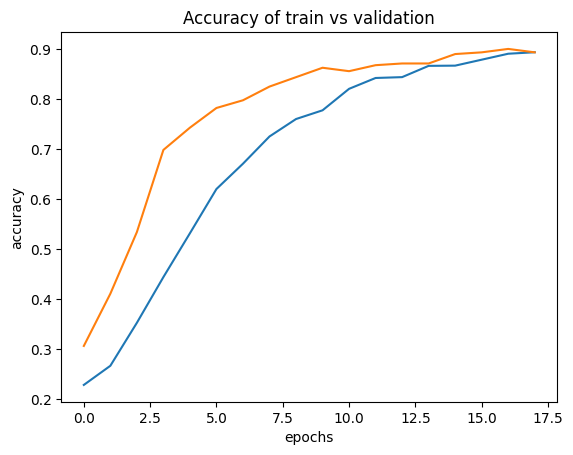

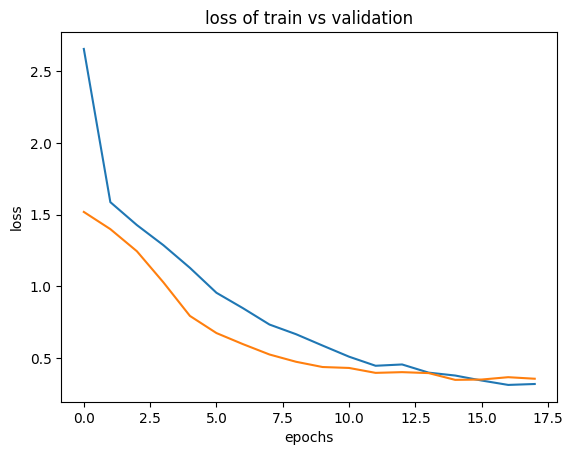

In [ ]:
## Plot training & validation accuracy
plt.plot(history.history['accuracy'], label='model accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend
plt.title('Accuracy of train vs validation')
plt.show()
## Plot training & validation loss
plt.plot(history.history['loss'], label='model loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend
plt.title('loss of train vs validation')
plt.show()

In [ ]:
val_loss, val_acc = model.evaluate(val_generator)
print("Validation Accuracy:", val_acc)

19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 566ms/step - accuracy: 0.8747 - loss: 0.4919
Validation Accuracy: 0.8972602486610413


In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)

23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 231ms/step - accuracy: 0.3169 - loss: 1.5263
Test Accuracy: 0.30570653080940247


In [ ]:
model.save('flower_recognizer.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


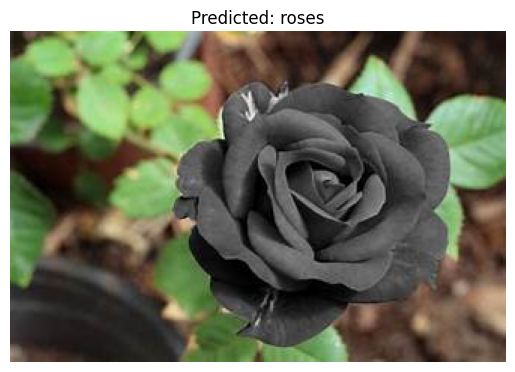

In [ ]:
import tensorflow as tf
# Load trained model
model = tf.keras.models.load_model("flower_recognizer.h5")

#Path to your new image
img_path = 'rose.jfif' # change this

#Load and preprocess the image (same preprocessing as training)
img_height, img_width = 256, 256  # change if different
img = tf.keras.utils.load_img(img_path, target_size=(img_height, img_width))
img_array = tf.keras.utils.img_to_array(img) / 255.0  # scale to 0-1
img_array = np.expand_dims(img_array, axis=0)
#predict
predictions = model.predict(img_array)
predicted_class = np.argmax(predictions[0]) #This is the predicted probability distribution for your first image in the batch, first row

#If you have class names
class_names = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']  # update accordingly
predicted_label = class_names[predicted_class]

#Display image in correct colors
plt.imshow(tf.keras.utils.load_img(img_path))  # original colors
plt.title(f"Predicted: {predicted_label}")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 711ms/step


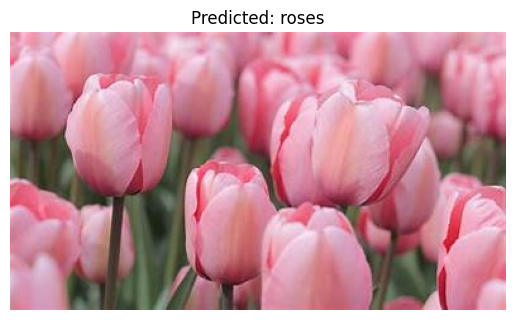

In [ ]:
import tensorflow as tf
# Load trained model
model = tf.keras.models.load_model("flower_recognizer.h5")

#Path to your new image
img_path = 'tulip.jfif' # change this

#Load and preprocess the image (same preprocessing as training)
img_height, img_width = 256, 256  # change if different
img = tf.keras.utils.load_img(img_path, target_size=(img_height, img_width))
img_array = tf.keras.utils.img_to_array(img) / 255.0  # scale to 0-1
img_array = np.expand_dims(img_array, axis=0)  #Neural networks expect input in batches — even if you only want to predict a single image.
                                               #model expects (batch_size, height, width, channels)  → e.g. (1, 256, 256, 3)
                                               #Adding axis=0 changes:(256, 256, 3) → (1, 256, 256, 3)where 1 is the batch size (one image in this batch).
#Predict
predictions = model.predict(img_array)
predicted_class = np.argmax(predictions[0]) #This is the predicted probability distribution for your first image in the batch, first row

#If you have class names
class_names = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']  # update accordingly
predicted_label = class_names[predicted_class]

#Display image in correct colors
plt.imshow(tf.keras.utils.load_img(img_path))  # original colors
plt.title(f"Predicted: {predicted_label}")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 750ms/step


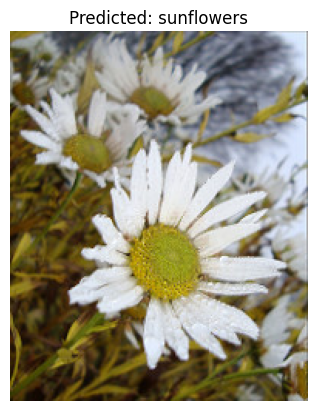

In [ ]:
#Testing random image from the dataset
import tensorflow as tf
# Path to dataset
model = tf.keras.models.load_model("flower_recognizer.h5")
dataset_path = "dataset/test"
class_names = os.listdir(dataset_path)
class_folder=random.choice(class_names)
image_file=random.choice(os.listdir(os.path.join(dataset_path, class_folder)))
img_path=os.path.join(dataset_path, class_folder, image_file)
img=tf.keras.utils.load_img(img_path, target_size=(256,256))
img_array=tf.keras.utils.img_to_array(img)
img_array=np.expand_dims(img_array, axis=0)
img_array=preprocess_input(img_array)
predictions=model.predict(img_array) #Run the image through your trained model; you get a probability vector per class.
predicted_class=np.argmax(predictions[0]) #np.argmax(pred[0]) finds the index of the highest probability. Use that index to map back to a class name.
predicted_label=class_names[predicted_class]
plt.imshow(tf.keras.utils.load_img(img_path))
plt.title((f"Predicted: {predicted_label}"))
plt.axis('off')
plt.show()


In [ ]:
print(train_generator.class_indices)
print(val_generator.class_indices)
print(test_generator.class_indices)
